Class: backhand  |  File: 'Screenshot 2026-05-07 at 6.05.12\u202fPM.png'  |  Shape: (254, 168, 3)


I0000 00:00:1778191519.789773 35431068 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1778191519.849234 35431070 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778191519.875518 35431070 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Poses detected: 1


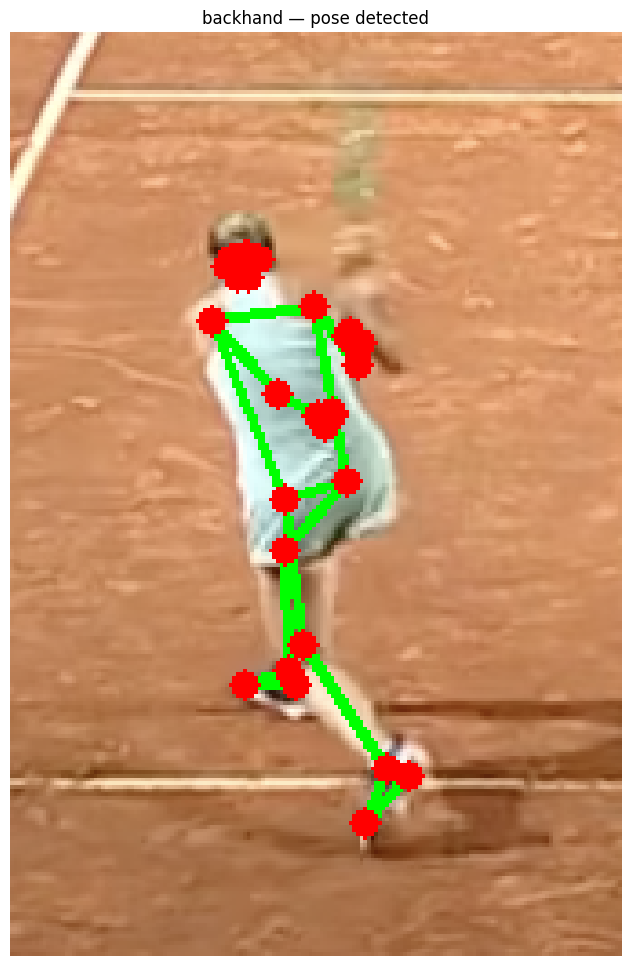

In [143]:
import sys
sys.path.insert(0, '../')
%matplotlib inline
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

POSE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19), (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)]
MODEL_PATH = '/Users/liu_michael/Documents/tennis-cv-analysis/models/pose_landmarker.task'
DATA_DIR   = '/Users/liu_michael/Documents/tennis-cv-analysis/pose_estimation/data'

# ── change this to 'forehand', 'backhand', or 'serve' ──
CLASS = 'backhand'

folder = os.path.join(DATA_DIR, CLASS)
images = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
fname  = max(images, key=lambda f: os.path.getmtime(os.path.join(folder, f)))
img_rgb = np.array(Image.open(os.path.join(folder, fname)).convert('RGB'))
print(f'Class: {CLASS}  |  File: {repr(fname)}  |  Shape: {img_rgb.shape}')

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.PoseLandmarkerOptions(base_options=base_options)
with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = landmarker.detect(mp_image)

print('Poses detected:', len(result.pose_landmarks))

if result.pose_landmarks:
    landmarks = result.pose_landmarks[0]
    h, w = img_rgb.shape[:2]
    annotated = img_rgb.copy()
    for a, b in POSE_CONNECTIONS:
        x1, y1 = int(landmarks[a].x * w), int(landmarks[a].y * h)
        x2, y2 = int(landmarks[b].x * w), int(landmarks[b].y * h)
        cv2.line(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for lm in landmarks:
        cv2.circle(annotated, (int(lm.x * w), int(lm.y * h)), 4, (255, 0, 0), -1)
    plt.figure(figsize=(8, 12))
    plt.imshow(annotated)
    plt.axis('off')
    plt.title(f'{CLASS} — pose detected')
    plt.show()

else:
    plt.figure(figsize=(8, 12))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'{CLASS} — no pose detected')
    plt.show()